# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [2]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv') #completa el código
usage = pd.read_csv('/datasets/usage.csv') #completa el código

In [4]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [5]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [6]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [7]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [8]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [9]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [10]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [11]:
# cantidad de nulos para users
print(users.isna().sum()) # Cantidad de valores nulos)
print(users.isna().mean()) # Proporción de valores nulos)

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [12]:
# cantidad de nulos para usage
print(usage.isna().sum())

print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

### Valores nulos

#### Dataset users

- La columna `city` presenta 469 valores nulos (11.73% del total).
  - Se trata de una proporción moderada de datos faltantes. Se recomienda investigar la causa de los nulos y evaluar una imputación utilizando la ciudad más frecuente o una categoría como "Desconocida" para no perder registros.

- La columna `churn_date` presenta 3,534 valores nulos (88.35% del total).
  - Esta proporción es muy alta; no se recomienda eliminar ni imputar estos valores hasta validar su significado.

#### Dataset usage

- La columna `date` presenta 50 valores nulos (0.13% del total).
  - La proporción es muy baja, por lo que podría eliminarse sin afectar significativamente el análisis.

- La columna `duration` presenta 22,076 valores nulos (55.19% del total).
  - La proporción es alta. Dado que el dataset contiene diferentes tipos de actividad (llamadas y mensajes), es probable que los registros de mensajes no tengan duración asociada. Se recomienda validar esta hipótesis antes de imputar o eliminar datos.

- La columna `length` presenta 17,896 valores nulos (44.74% del total).
  - La proporción es alta. Se recomienda analizar la relación entre `type` y `length` antes de realizar cualquier tratamiento.

#### Conclusión

Los nulos observados en `duration`, `length` y `churn_date` podrían corresponder al comportamiento normal del negocio y no necesariamente a errores de calidad de datos. Antes de imputar o eliminar registros, es necesario investigar si los valores faltantes están asociados al tipo de actividad o al estado del cliente.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [14]:
# explorar columnas numéricas de users
users[['user_id', 'age']].describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` actúa como identificador único de los clientes. Los valores observados se encuentran dentro de un rango consistente y no presentan indicios de valores inválidos.

- La columna `age` presenta un valor mínimo de `-999`, el cual no es válido para una edad y probablemente corresponde a un sentinel utilizado para representar información faltante. Este valor deberá ser reemplazado por `NaN` durante la etapa de limpieza para evitar sesgos en el análisis estadístico.

In [15]:
# explorar columnas numéricas de usage
usage[['id', 'user_id', 'duration', 'length']].describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000



- La columna `id` corresponde al identificador de cada registro y presenta valores consistentes sin indicios de errores o sentinels.

- La columna `user_id` contiene identificadores de usuarios dentro del mismo rango observado en el dataset de clientes, por lo que no presenta inconsistencias aparentes.

- La columna `duration` presenta valores entre 0 y 120 minutos. No se detectan valores negativos ni sentinels evidentes, por lo que los datos parecen válidos.

- La columna `length` presenta valores entre 0 y 1490 caracteres. No se observan valores negativos ni sentinels; sin embargo, los valores más altos podrían revisarse posteriormente como posibles outliers durante el análisis exploratorio.

In [25]:
# explorar columnas categóricas de users

users['plan'].value_counts(dropna=False)
users['city'].value_counts(dropna=False)

Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64


- La columna `city` contiene ciudades válidas como Bogotá, CDMX, Medellín, GDL, Cali y MTY. Sin embargo, se identifican 469 valores nulos y 96 registros con el valor `?`, el cual parece actuar como un sentinel para representar información desconocida o faltante. Se recomienda reemplazar `?` por `NaN` durante la etapa de limpieza.

- La columna `plan` contiene únicamente dos categorías (`Basico` y `Premium`) y no presenta valores nulos ni categorías inconsistentes. No se detectan problemas de calidad en esta variable.

In [26]:
# explorar columna categórica de usage
usage['type'].value_counts(dropna=False) # completa el código

text    22092
call    17908
Name: type, dtype: int64

- La columna `type` contiene únicamente dos categorías válidas: `text` y `call`, correspondientes a mensajes y llamadas respectivamente. No presenta valores nulos ni categorías inconsistentes, por lo que no se detectan problemas de calidad ni sentinels en esta variable.

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?

### Valores inválidos o sentinels

Durante la exploración de las variables numéricas y categóricas se identificaron los siguientes valores inválidos:

- En la columna `age` se encontró el valor `-999`, el cual no corresponde a una edad válida y parece utilizarse como sentinel para representar información faltante.
- En la columna `city` se identificó la categoría `?`, la cual probablemente representa una ciudad desconocida o no informada y debe considerarse un valor faltante.

### Acción recomendada

- Reemplazar el valor `-999` de la columna `age` por `NaN` para evitar que afecte los cálculos estadísticos.
- Reemplazar el valor `?` de la columna `city` por `NaN` para tratarlo como dato faltante.
- No se detectaron sentinels ni valores inválidos en las columnas `plan`, `type`, `duration`, `length`, `user_id` o `id`.
- Tras reemplazar estos sentinels, se deberá evaluar la estrategia más adecuada para tratar los valores faltantes generados.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [29]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce') # completa el código

In [30]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce') # completa el código

In [31]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts().sort_index()

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

En `reg_date` se identifican registros de los años 2022, 2023 y 2024, que son coherentes con el período de análisis. Sin embargo, también aparecen 40 registros con fecha de registro en 2026. Dado que el proyecto indica que la información está disponible hasta 2024, estas fechas podrían corresponder a errores de captura y deberían revisarse antes de continuar con el análisis.

In [32]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts().sort_index()

2024.0    39950
Name: date, dtype: int64

En `date` todos los registros corresponden al año 2024, por lo que las fechas son consistentes con el período definido para el análisis. No se observan años fuera de rango ni fechas futuras.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

### Fechas fuera de rango

- Se identificaron 40 registros en la columna `reg_date` con fecha en el año 2026.
- Dado que el proyecto indica que la información disponible llega únicamente hasta 2024, estas fechas se consideran fuera del rango esperado y podrían corresponder a errores de captura o carga de datos.
- En la columna `date` no se detectaron fechas fuera de rango, ya que todos los registros corresponden al año 2024.

### Acción recomendada

- Revisar los registros con fecha de 2026 para confirmar si se trata de un error.
- Si no es posible validar la fecha correcta, se recomienda excluir estos registros del análisis o marcarlos como valores faltantes para evitar sesgos en los resultados.
- Mantener sin cambios la columna `date`, ya que sus valores son consistentes con el período de análisis.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [33]:
# Reemplazar -999 por la mediana de age

age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [34]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].value_counts(dropna=False)

Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [38]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].dt.year.value_counts(dropna=False).sort_index()

2022.0    1314
2023.0    1316
2024.0    1330
NaN         40
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [40]:
# Verificación MAR en usage (Missing At Random) para length
usage.groupby('type')[['duration', 'length']].apply(lambda x: x.isna().sum())

,duration,length
type,,
call,0,17896
text,22076,0


### Diagnóstico de nulos en `duration` y `length`

Se verificó la relación entre los valores nulos y la columna `type`.

- En los registros de tipo `call`, la columna `duration` no presenta valores nulos, mientras que `length` es nula en todos los casos.
- En los registros de tipo `text`, la columna `length` no presenta valores nulos, mientras que `duration` es nula en todos los casos.

Esto indica que los valores faltantes dependen directamente del tipo de actividad registrada y no corresponden a errores de captura o calidad de datos.

### Acción recomendada

Los nulos en `duration` y `length` deben mantenerse sin imputar, ya que representan el comportamiento normal del negocio:
- Las llamadas tienen duración pero no longitud de mensaje.
- Los mensajes tienen longitud pero no duración.

Por lo tanto, estos valores faltantes pueden considerarse MAR (Missing At Random respecto a la variable observada `type`) y no requieren corrección.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [41]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg({
    "is_text": "sum",
    "is_call": "sum",
    "duration": "sum"
}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [42]:
# Renombrar columnas
usage_agg.columns = [
    "user_id",
    "cant_mensajes",
    "cant_llamadas",
    "cant_minutos_llamada"
]
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [43]:
# Combinar la tabla agregada con el dataset de usuarios

user_profile = users.merge(usage_agg, on="user_id", how="left")

user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [44]:
# Resumen estadístico de las columnas numéricas
user_profile[['age',
              'cant_mensajes',
              'cant_llamadas',
              'cant_minutos_llamada']].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [45]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

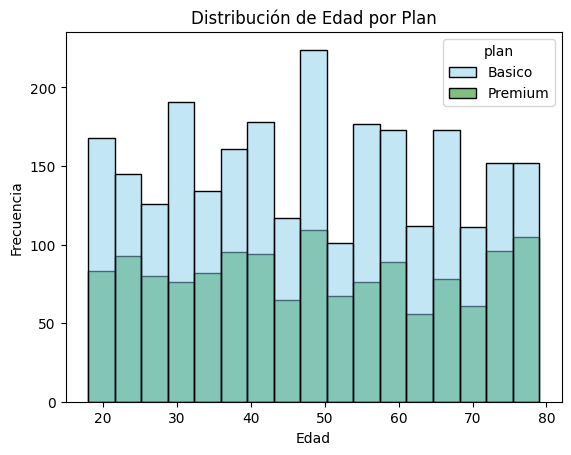

In [46]:
# Histograma para visualizar la edad (age)
sns.histplot(
    data=user_profile,
    x='age',
    hue='plan',
    palette=['skyblue', 'green']
)

plt.title('Distribución de Edad por Plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- La distribución de edades es bastante uniforme entre los 18 y 79 años, sin concentraciones extremas en un grupo etario específico.
- El plan Básico presenta una mayor cantidad de usuarios en prácticamente todos los rangos de edad, lo que es consistente con su mayor participación dentro de la base de clientes.
- No se observan diferencias significativas en la distribución de edades entre los usuarios de los planes Básico y Premium, por lo que la edad no parece ser un factor determinante en la elección del plan.
- La distribución puede considerarse relativamente uniforme, sin un sesgo marcado hacia edades jóvenes o mayores.

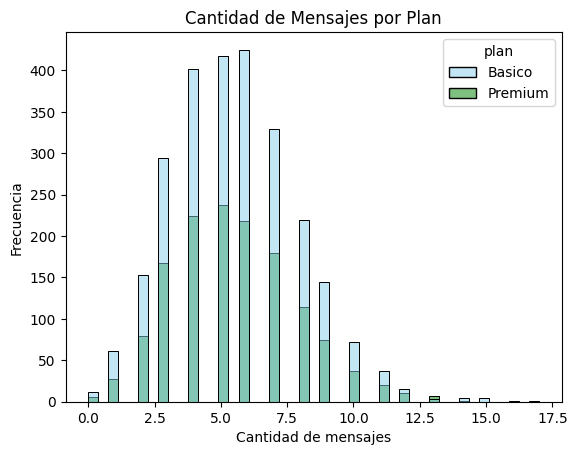

In [47]:
# Histograma para visualizar la cant_mensajes
sns.histplot(
    data=user_profile,
    x='cant_mensajes',
    hue='plan',
    palette=['skyblue', 'green']
)

plt.title('Cantidad de Mensajes por Plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- La mayor parte de los usuarios envía entre 3 y 8 mensajes durante el período analizado, concentrándose especialmente alrededor de 5 o 6 mensajes.
- Tanto los usuarios del plan Básico como los del plan Premium presentan patrones de uso muy similares en cuanto al envío de mensajes.
- Se observa una distribución sesgada a la derecha, ya que existe un pequeño grupo de usuarios que envía una cantidad significativamente mayor de mensajes que el resto.
- No se aprecian diferencias importantes entre los planes Básico y Premium respecto al volumen de mensajes enviados, lo que sugiere que el tipo de plan no influye significativamente en este comportamiento.

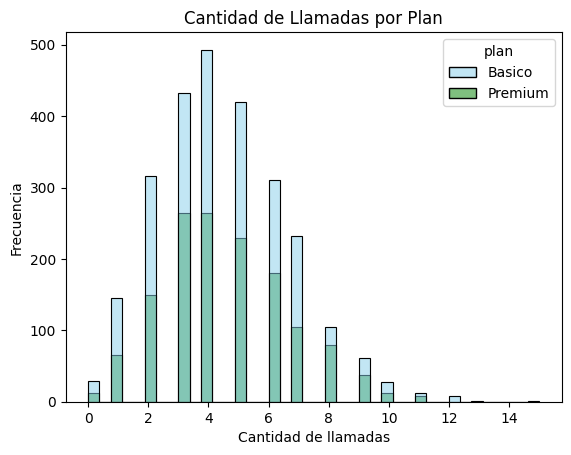

In [48]:
# Histograma para visualizar la cant_llamadas


💡Insights: 
- La mayoría de los usuarios realiza entre 2 y 7 llamadas durante el período analizado, con una concentración importante alrededor de 4 y 5 llamadas.
- Los usuarios de los planes Básico y Premium muestran un comportamiento muy similar en cuanto al número de llamadas realizadas.
- La distribución presenta un sesgo hacia la derecha, ya que existe un pequeño grupo de usuarios que realiza muchas más llamadas que el promedio.
- No se observan diferencias significativas entre los planes Básico y Premium respecto a la cantidad de llamadas, lo que sugiere que el tipo de plan no influye de forma relevante en este patrón de uso.
- Los usuarios con más de 10 llamadas podrían analizarse posteriormente como posibles casos de uso intensivo o valores atípicos.

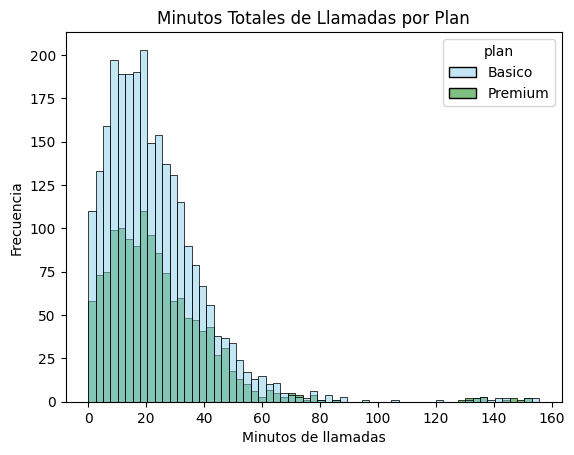

In [49]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(
    data=user_profile,
    x='cant_minutos_llamada',
    hue='plan',
    palette=['skyblue', 'green']
)

plt.title('Minutos Totales de Llamadas por Plan')
plt.xlabel('Minutos de llamadas')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
 La mayoría de los usuarios acumula entre 5 y 35 minutos de llamadas durante el período analizado.
- La distribución presenta un claro sesgo hacia la derecha, ya que existe un grupo reducido de usuarios con una cantidad de minutos significativamente superior al resto.
- Se observan posibles valores atípicos, especialmente en usuarios que superan los 100 minutos de llamadas, alcanzando incluso valores cercanos a 150 minutos.
- Los usuarios de los planes Básico y Premium muestran patrones similares en los rangos más frecuentes de uso; sin embargo, algunos usuarios Premium parecen concentrar mayores volúmenes de minutos en la parte alta de la distribución.
- Estos usuarios de alto consumo podrían representar un segmento de clientes intensivos y conviene analizarlos con mayor detalle en la sección de detección de outliers.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

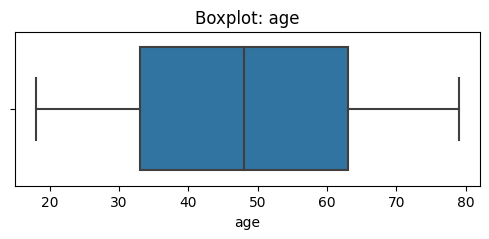

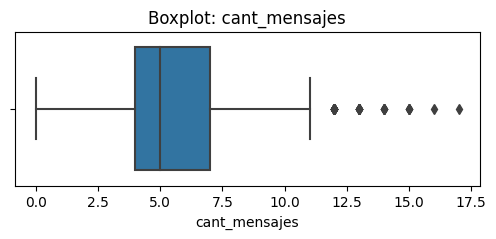

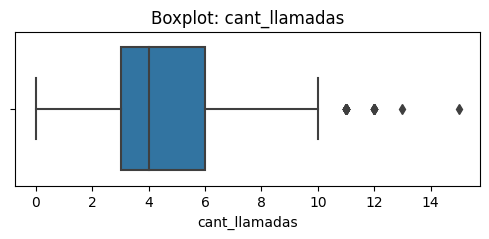

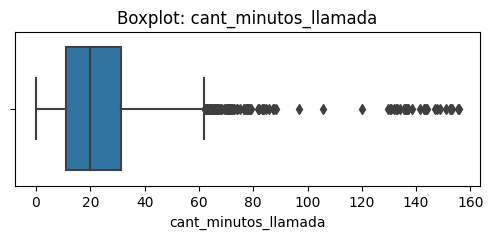

In [50]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=user_profile[col])
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights: 

- **age:** No se observan outliers. La distribución de edades se encuentra dentro de un rango razonable y los valores parecen consistentes para una base de clientes de telecomunicaciones.

- **cant_mensajes:** Se identifican algunos outliers en el extremo superior (usuarios con aproximadamente 12 a 17 mensajes). Estos casos representan usuarios con una actividad de mensajería superior al promedio.

- **cant_llamadas:** Se observan algunos outliers superiores (usuarios con aproximadamente 11 a 15 llamadas). Estos registros podrían corresponder a clientes con un uso más intensivo del servicio.

- **cant_minutos_llamada:** Es la variable con mayor cantidad de outliers. Se identifican usuarios con un volumen de minutos muy superior al resto, alcanzando valores cercanos a 150 minutos. Esto indica la existencia de un segmento de usuarios de alto consumo.

  

In [51]:
# Calcular límites con el método IQR
columnas_limites = [...]

columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:

    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)

    IQR = Q3 - Q1

    limite_superior = Q3 + 1.5 * IQR

    print(f"\n{col}")
    print("Límite superior:", limite_superior)


cant_mensajes
Límite superior: 11.5

cant_llamadas
Límite superior: 10.5

cant_minutos_llamada
Límite superior: 61.8575


In [52]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 

- **cant_mensajes:** El límite superior calculado mediante el método IQR es 11.5 mensajes, mientras que el valor máximo observado es 17 mensajes. Aunque existen algunos usuarios por encima del límite estadístico, la diferencia no es extrema y estos registros pueden representar clientes con un uso intensivo del servicio de mensajería. Se recomienda mantener los outliers, ya que reflejan comportamientos reales del negocio.

- **cant_llamadas:** El límite superior es 10.5 llamadas y el valor máximo observado es 15 llamadas. Los usuarios que superan este umbral representan una proporción reducida de la muestra y no muestran valores imposibles o inconsistentes. Se recomienda conservar estos registros porque aportan información sobre clientes con una frecuencia de llamadas superior al promedio.

- **cant_minutos_llamada:** El límite superior calculado es 61.86 minutos, mientras que el valor máximo alcanza 155.69 minutos. Aunque esta variable presenta los outliers más pronunciados, estos valores son plausibles dentro del contexto de telecomunicaciones y podrían corresponder a usuarios con un consumo intensivo. Se recomienda mantener estos registros, ya que constituyen un segmento relevante para el análisis de comportamiento y el diseño de planes comerciales.

### Conclusión

Los outliers identificados en las variables de uso superan los límites definidos por el método IQR, pero no corresponden a errores de captura ni a valores imposibles. Debido a que representan comportamientos reales de usuarios de alto consumo, se recomienda mantenerlos en el análisis para no perder información valiosa sobre segmentos importantes del negocio.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [56]:
# Crear columna grupo_uso
def clasificar_uso(row):
    if (row['cant_llamadas'] < 5) and (row['cant_mensajes'] < 5):
        return 'Bajo uso'
    elif (row['cant_llamadas'] < 10) and (row['cant_mensajes'] < 10):
        return 'Uso medio'
    else:
        return 'Alto uso'

user_profile['grupo_uso'] = user_profile.apply(clasificar_uso, axis=1)

In [57]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [58]:
# Crear columna grupo_edad
def clasificar_edad(row):
    if row['age'] < 30:
        return 'Joven'
    elif row['age'] < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

user_profile['grupo_edad'] = user_profile.apply(clasificar_edad, axis=1)

In [59]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

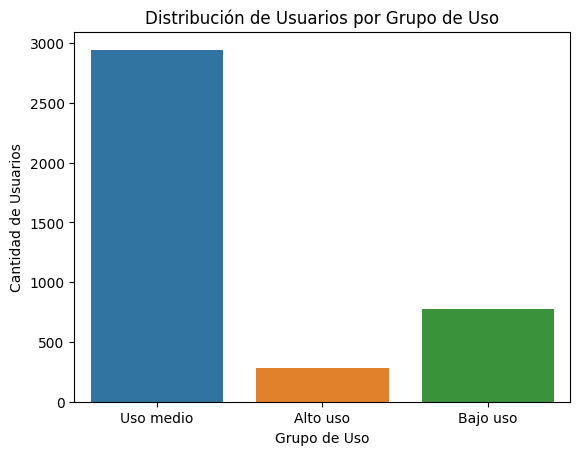

In [60]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso')

plt.title('Distribución de Usuarios por Grupo de Uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de Usuarios')

plt.show()

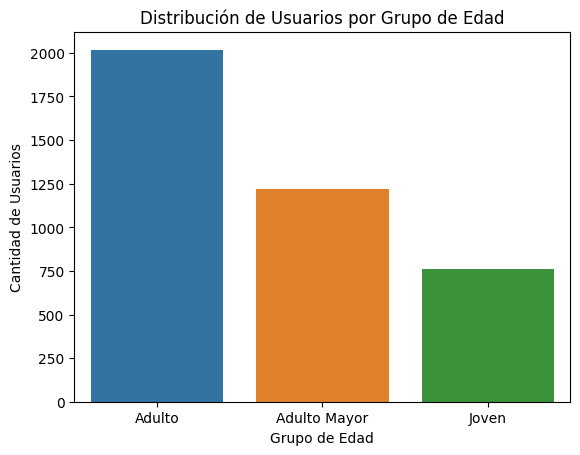

In [61]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad')

plt.title('Distribución de Usuarios por Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Usuarios')

plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Se identificó un valor sentinel (-999) en la columna age, el cual fue reemplazado por la mediana para evitar distorsiones en el análisis.
- En la columna city se detectó la categoría ?, utilizada como valor inválido o desconocido, por lo que fue reemplazada por valores nulos.
- Se encontraron 40 registros con fechas de registro en 2026, aunque el período de análisis llega hasta 2024. Estas fechas fueron marcadas como nulas por considerarse fuera de rango.
- Los valores nulos observados en duration y length no corresponden a errores de calidad, sino al comportamiento normal del negocio: las llamadas tienen duración pero no longitud de mensaje, mientras que los mensajes tienen longitud pero no duración.

🔍 **Segmentos por Edad**
- El segmento predominante corresponde a los usuarios Adultos (30 a 59 años), representando aproximadamente la mitad de la base de clientes.
- Los grupos de Jóvenes y Adultos Mayores tienen una participación menor, siendo los jóvenes el segmento menos representado.
- La distribución de edades es relativamente uniforme y no muestra concentraciones extremas ni outliers relevantes.
- La edad no parece ser un factor determinante en la elección entre los planes Básico y Premium, ya que ambos planes presentan distribuciones similares.

📊 **Segmentos por Nivel de Uso**
- La mayoría de los clientes pertenece al segmento de Uso Medio, lo que indica un comportamiento moderado tanto en llamadas como en mensajes.
- El segmento de Bajo Uso representa una proporción menor de la base de clientes.
- Los usuarios de Alto Uso constituyen el grupo más reducido, pero son especialmente relevantes para el negocio debido a su elevado nivel de consumo.
- Se identificaron usuarios con volúmenes de mensajes, llamadas y minutos superiores a los límites definidos por el método IQR. Sin embargo, estos registros representan comportamientos reales y no errores de captura.

➡️ Esto sugiere que ...
- El cliente típico de ConnectaTel es un usuario adulto con un nivel de consumo medio de llamadas y mensajes.
- Existe un grupo reducido de clientes de alto consumo que podría beneficiarse de planes especializados con mayores beneficios o servicios adicionales.
- Los outliers detectados representan oportunidades comerciales más que problemas de calidad de datos, ya que reflejan usuarios con patrones de uso intensivo.
- La compañía cuenta con una base de clientes relativamente estable, sin diferencias extremas de comportamiento entre los planes Básico y Premium.

💡 **Recomendaciones**
- Diseñar ofertas específicas para los usuarios de Alto Uso, incluyendo paquetes con mayores beneficios en llamadas y mensajería.
- Implementar campañas de fidelización dirigidas a los clientes de consumo intensivo, ya que representan un segmento de alto valor para la compañía.
- Analizar con mayor profundidad el comportamiento de los usuarios de Bajo Uso para identificar oportunidades de activación y aumento de consumo.
- Mantener controles de calidad de datos para evitar la aparición de sentinels, valores inválidos y fechas fuera de rango en futuras cargas de información.
- Explorar estrategias comerciales diferenciadas para los segmentos de jóvenes y adultos mayores, adaptando los beneficios de los planes a sus patrones de uso.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`